In [1]:
import os
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import os
import librosa
import numpy as np
from collections import defaultdict

TARGET_DURATION = 10
SEGMENT_LENGTH = 2
SAMPLE_RATE = 16000


In [2]:
data_path = '/home/aljaz/Desktop/workspace/FERI/magisterij/ROSIS/09_remove_noise/datasets/librispeech/LibriSpeech/dev-clean'

In [3]:
file_data = []
for speaker_id in os.listdir(data_path):
    speaker_path = os.path.join(data_path, speaker_id)
    if os.path.isdir(speaker_path):
        for chapter_id in os.listdir(speaker_path):
            chapter_path = os.path.join(speaker_path, chapter_id)
            if os.path.isdir(chapter_path):
                for file_name in os.listdir(chapter_path):
                    if file_name.endswith('.flac'):
                        file_path = os.path.join(chapter_path, file_name)
                        try:
                            # Pridobivanje informacij o posnetku
                            y, sr = librosa.load(file_path)
                            duration = librosa.get_duration(y=y, sr=sr)
                            file_data.append({
                                'speaker_id': speaker_id,
                                'duration': duration,
                                'sample_rate': sr,
                                'path': file_path
                            })
                        except Exception as e:
                            print(f"Napaka pri obdelavi datoteke {file_path}: {e}")

df = pd.DataFrame(file_data)

Število govorcev: 40
Število vseh posnetkov: 2703

Statistika števila posnetkov na govorca:
count     40.00000
mean      67.57500
std       16.71463
min       36.00000
25%       56.50000
50%       68.00000
75%       78.00000
max      101.00000
dtype: float64

Statistika dolžine posnetkov (v sekundah):
count    2703.000000
mean        7.175791
std         4.695612
min         1.445034
25%         3.760000
50%         5.920000
75%         9.267528
max        32.645034
Name: duration, dtype: float64

Najpogostejša vzorčevalna frekvenca: 22050 Hz


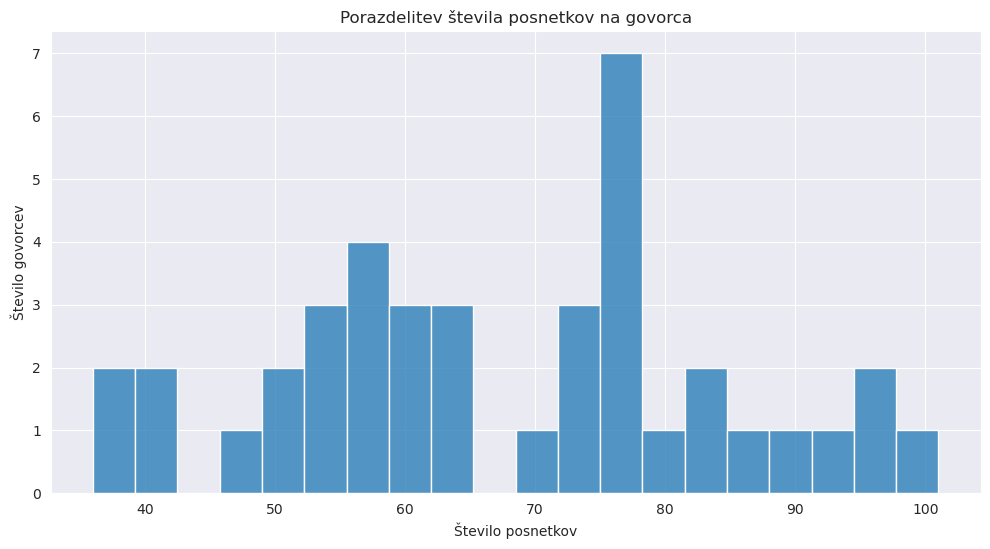

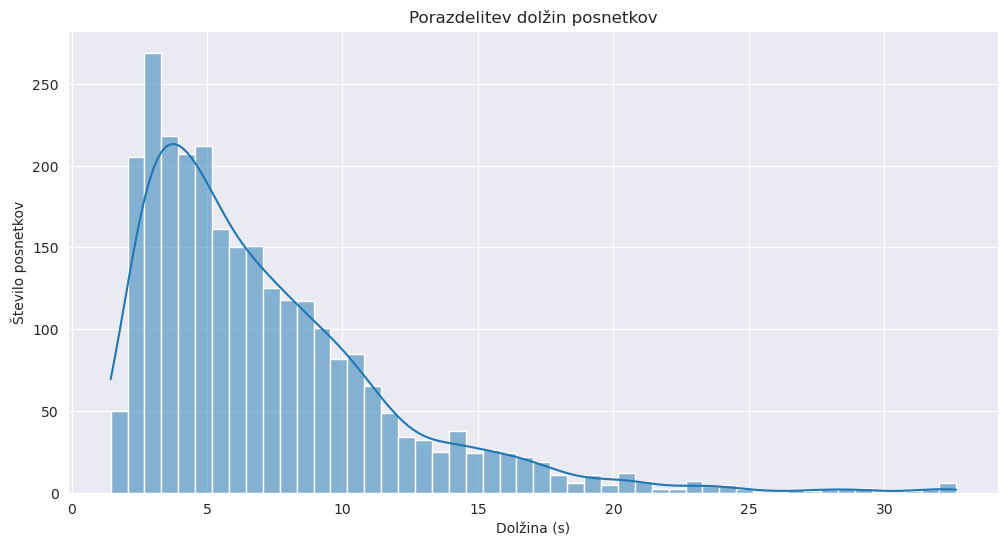

In [4]:
# Izračuni za poročilo
num_speakers = df['speaker_id'].nunique()
num_recordings = len(df)
recordings_per_speaker = df.groupby('speaker_id').size()
duration_stats = df['duration'].describe()

print(f"Število govorcev: {num_speakers}")
print(f"Število vseh posnetkov: {num_recordings}")
print("\nStatistika števila posnetkov na govorca:")
print(recordings_per_speaker.describe())
print(f"\nStatistika dolžine posnetkov (v sekundah):")
print(duration_stats)
print(f"\nNajpogostejša vzorčevalna frekvenca: {df['sample_rate'].mode()[0]} Hz")

# Histogram porazdelitve števila posnetkov na govorca
plt.figure(figsize=(12, 6))
sns.histplot(recordings_per_speaker, bins=20, kde=False)
plt.title('Porazdelitev števila posnetkov na govorca')
plt.xlabel('Število posnetkov')
plt.ylabel('Število govorcev')
plt.grid(True)
plt.show()

# Histogram porazdelitve dolžin posnetkov
plt.figure(figsize=(12, 6))
sns.histplot(df['duration'], bins=50, kde=True)
plt.title('Porazdelitev dolžin posnetkov')
plt.xlabel('Dolžina (s)')
plt.ylabel('Število posnetkov')
plt.grid(True)
plt.show()


In [5]:
TARGET_DURATION = 10  # sekunde
SEGMENT_LENGTH = 2    # sekunde
SAMPLE_RATE = 16000   # Standard za LibriSpeech

In [8]:
def process_and_segment_audio(file_path):
    # Naloži avdio in poenoti vzorčevalno frekvenco
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE)

    # 1. Obreži na največ 10 sekund
    if len(y) > TARGET_DURATION * sr:
        y = y[:TARGET_DURATION * sr]

    # 2. Razreži na 2-sekundne kose
    segment_samples = SEGMENT_LENGTH * sr
    segments = []
    for start in range(0, len(y) - segment_samples + 1, segment_samples):
        segment = y[start:start + segment_samples]
        segments.append(segment)

    return segments

In [7]:
# Parametri za Mel spektrogram (za poročanje)
N_FFT = 2048         # Dolžina FFT okna vecja vrednost finejsa kot je frekvenca - zmanjsanje casovno locljivost
HOP_LENGTH = 512     # Korak premika okna - manjse -vecje prekrivanje med okni razdalja med zacetki sosednjih oken
N_MELS = 128         # Število Mel filtrov

def extract_mel_spectrogram(audio_segment):
    mel_spectrogram = librosa.feature.melspectrogram(
        y=audio_segment,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )
    # Pretvorba v decibele (logaritemska skala)
    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)
    return log_mel_spectrogram

# To funkcijo uporabite na vsakem 2-sekundnem segmentu

In [9]:

# Slovar za shranjevanje segmentov
# defaultdict je uporaben, ker sam ustvari prazen seznam za nove ključe
speaker_segments = defaultdict(list)

print("Začenjam zbiranje in segmentacijo avdio datotek...")
# Iteracija čez strukturo LibriSpeech
for speaker_id in os.listdir(data_path):
    speaker_path = os.path.join(data_path, speaker_id)
    if not os.path.isdir(speaker_path):
        continue

    for chapter_id in os.listdir(speaker_path):
        chapter_path = os.path.join(speaker_path, chapter_id)
        if not os.path.isdir(chapter_path):
            continue

        for file_name in os.listdir(chapter_path):
            if file_name.endswith('.flac'):
                file_path = os.path.join(chapter_path, file_name)

                # Uporaba funkcije iz prejšnjega koraka
                # Predpostavimo, da sta funkciji process_and_segment_audio in extract_mel_spectrogram definirani
                segments = process_and_segment_audio(file_path) # Vrne seznam surovih avdio segmentov

                # Dodajanje segmentov v slovar
                speaker_segments[speaker_id].extend(segments)

print(f"Končano. Zbranih {sum(len(v) for v in speaker_segments.values())} segmentov od {len(speaker_segments)} govorcev.")

Začenjam zbiranje in segmentacijo avdio datotek...
Končano. Zbranih 7400 segmentov od 40 govorcev.


In [10]:
import random

# Pridobi seznam vseh unikatnih ID-jev govorcev
all_speaker_ids = list(speaker_segments.keys())
random.shuffle(all_speaker_ids) # Dobro je premešati za naključno razdelitev

# Definiramo razmerja
train_split = 0.8
val_split = 0.1
# test_split je preostanek (0.1)

# Izračunamo meje za rezanje seznama
train_idx_end = int(len(all_speaker_ids) * train_split)
val_idx_end = train_idx_end + int(len(all_speaker_ids) * val_split)

# Razdelimo ID-je govorcev
train_speaker_ids = all_speaker_ids[:train_idx_end]
val_speaker_ids = all_speaker_ids[train_idx_end:val_idx_end]
test_speaker_ids = all_speaker_ids[val_idx_end:]

print(f"Velikosti množic (po številu govorcev):")
print(f"  - Učna: {len(train_speaker_ids)} govorcev")
print(f"  - Validacijska: {len(val_speaker_ids)} govorcev")
print(f"  - Testna: {len(test_speaker_ids)} govorcev")

Velikosti množic (po številu govorcev):
  - Učna: 32 govorcev
  - Validacijska: 4 govorcev
  - Testna: 4 govorcev


In [11]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# 1. Ustvarimo preslikavo iz ID govorca v celo število (label)
# Uporabimo vse govorce, da zagotovimo doslednost
all_unique_speakers = sorted(speaker_segments.keys())
speaker_to_int = {speaker: i for i, speaker in enumerate(all_unique_speakers)}

# Parametri za spektrogram
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

# Funkcija, ki ustvari množico (X, y) iz seznama ID-jev govorcev
def create_dataset(speaker_ids, all_segments_dict, mapping):
    X, y = [], []
    for speaker_id in speaker_ids:
        # Pridobi numerično oznako za govorca
        label = mapping[speaker_id]
        # Preidi čez vse segmente tega govorca
        for segment in all_segments_dict[speaker_id]:
            # Ekstrakcija značilk - Mel spektrogram
            mel_spec = extract_mel_spectrogram(segment) # Uporabi funkcijo iz koraka 2
            X.append(mel_spec)
            y.append(label)
    return np.array(X), np.array(y)

# 2. Ustvarimo množice
print("Ustvarjam učno množico...")
X_train, y_train = create_dataset(train_speaker_ids, speaker_segments, speaker_to_int)
print("Ustvarjam validacijsko množico...")
X_val, y_val = create_dataset(val_speaker_ids, speaker_segments, speaker_to_int)
print("Ustvarjam testno množico...")
X_test, y_test = create_dataset(test_speaker_ids, speaker_segments, speaker_to_int)

# 3. Finalizacija podatkov - priprava za Keras model
# Dodamo "kanalno" dimenzijo za CNN (greyscale kanal)
X_train = np.expand_dims(X_train, -1)
X_val = np.expand_dims(X_val, -1)
X_test = np.expand_dims(X_test, -1)

# One-hot kodiranje oznak
num_classes = len(all_unique_speakers)
y_train = to_categorical(y_train, num_classes=num_classes)
y_val = to_categorical(y_val, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

2025-07-06 16:47:56.349119: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751813276.459919    4888 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751813276.493363    4888 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-06 16:47:56.918897: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Ustvarjam učno množico...
Ustvarjam validacijsko množico...
Ustvarjam testno množico...


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, MaxPooling2D, GRU, Dense, TimeDistributed, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Predpostavimo, da imajo Mel spektrogrami obliko (n_mels, n_timesteps, 1)
# Za 2s posnetek pri 16kHz, hop=512, n_mels=128: (128, 63, 1)
input_shape = (N_MELS, 63, 1) # Izračunajte točno obliko glede na vaše parametre! stevilo mel filtrov stevilo casovnih korakov(dolzino zvocnega segmenta v casu) in stevilo kanalov
all_unique_speakers = sorted(speaker_segments.keys())
num_classes = len(all_unique_speakers)

# Osnovni model
model = Sequential([ # osnovni tip v keras kjer sloje nalagam zaporedno
    Input(shape=input_shape),  # model pricakuje podatke v 3d matrike

    # --- CNN Blok 1 --- cnn bloke so dobre za ekstrakcijo lokalnih vzorcev v podatkih - frekvence in cas znacilnosti v mel spektogrmaih
    Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'), # dela nad 2d konvolucijski sloj 32 je stevilo jeder filtrov ki bo sloj naucil
    # kernel size pove da bo vsak filter skeniral vhodne podatke v okn u3x3
    # relu vnasa nelinearnosti mv model kar omogoca ucenje kompleksnejsih vxorcev vse - vrednsoti da v 0 pozitivne pa pusti 
    # same  izhodna oblika sloja bo enaka kot vhodni
    BatchNormalization(), # normalizira podake v batch - uravnana sta povprecje in standardni odklon
    MaxPooling2D(pool_size=(2, 2)), # zmanjsa d vhodnih pdoatkov tako da vzame max vrednost iz vsakega 2x2 okna

    # --- CNN Blok 2 ---
    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # Priprava za RNN plast
    # (Višina frekvenčnih binov, časovni koraki, kanali) -> (časovni koraki, višina * kanali)
    tf.keras.layers.Reshape((-1, 32 * 64)), # Prilagodite glede na dimenzije po MaxPooling

    # --- RNN Plast ---
    # sloj primeren za obdelavo zapolomnih podatkov in imajo spomin na prejsnje elemente v zaporedji
    GRU(128, return_sequences=False), # GRU je hitrejši od LSTM boljsa za  obdelavo casovnih zaporedij in zajemanje dolgorocnih odvisnoti 
    # vec enot - kompleksnejsi stavri se lahko nauci 
    # vrne samo zadnje izhod iz zaporedja
    Dropout(0.5), # med vsakim korakom ucenja nakljucno izklopi 50 % nevronov s tem prepreci prekomerno prileganje s tem nevrone ne bod se prevec nanasali en na drug

    # --- Klasifikacijska Plast ---
    Dense(128, activation='relu'), # popolnoma povezan sloj ker je vsak nevron v sloju povezan z vsakim nevronom v prejsnem sloju
    # Uporabite dinamično spremenljivko namesto fiksne številke 100
    # 123 st nevronov v sloju in ta je skriti sloj ki oddano obedla znacilnosti pred koncno klasifikacijo
    Dense(num_classes, activation='softmax')
    # softmax za klasifikacije razreda
])

# Hiper-parametri
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 100 # Early stopping bo prekinil prej

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), # adam sam sem prilagaja
              loss='categorical_crossentropy', # Potrebujete one-hot kodirane labele
              metrics=['accuracy'])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 63, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 63, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 31, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 15, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 128)            │       836,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 40)             │         5,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 877,224 (3.35 MB)

 Trainable params: 877,032 (3.35 MB)

 Non-trainable params: 192 (768.00 B)

In [35]:
# Callback za zgodnjo prekinitev
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Callback za shranjevanje modela
model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

# Učenje modela
# X_train, y_train, X_val, y_val morate pripraviti prej
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, model_checkpoint]
)

# Shranjevanje učnih podatkov
import pickle
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

Epoch 1/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 96s 492ms/step - accuracy: 0.0814 - loss: 3.4507 - val_accuracy: 0.0000e+00 - val_loss: 9.1698
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 57s 309ms/step - accuracy: 0.2967 - loss: 2.3439 - val_accuracy: 0.0000e+00 - val_loss: 13.2604
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 61s 333ms/step - accuracy: 0.5966 - loss: 1.3015 - val_accuracy: 0.0000e+00 - val_loss: 15.0887
Epoch 4/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 61s 330ms/step - accuracy: 0.7469 - loss: 0.8203 - val_accuracy: 0.0000e+00 - val_loss: 15.8296
Epoch 5/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 61s 331ms/step - accuracy: 0.8280 - loss: 0.5568 - val_accuracy: 0.0000e+00 - val_loss: 15.7054
Epoch 6/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 62s 335ms/step - accuracy: 0.8789 - loss: 0.3953 - val_accuracy: 0.0000e+00 - val_loss: 16.9441
Epoch 7/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 61s 331ms/step - accuracy: 0.9155 - loss: 0.2657 - val_accuracy: 0.0000e+00 - val_loss: 18.4945
Epoch 8/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 6

In [36]:
def add_noise(signal, snr_db):
    signal_power = np.mean(signal ** 2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.random.normal(0, np.sqrt(noise_power), len(signal))
    return signal + noise

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step


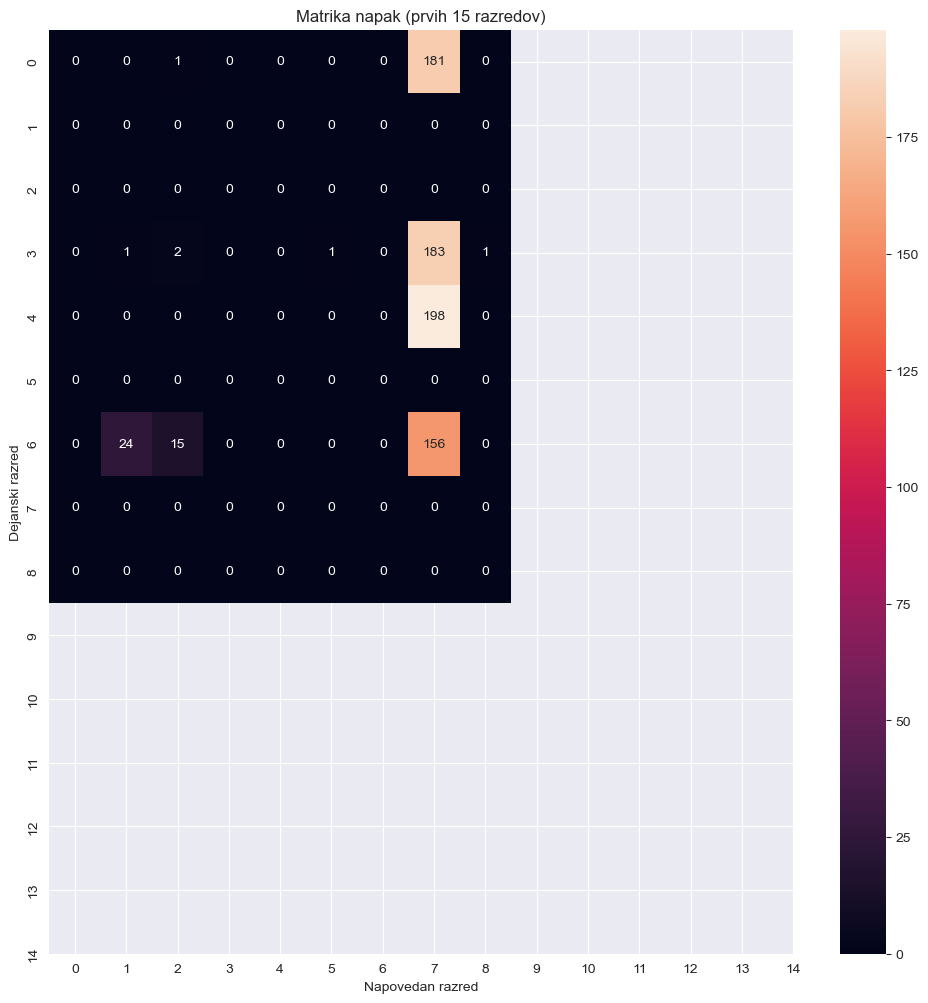

              precision    recall  f1-score   support

           6       0.00      0.00      0.00     182.0
          10       0.00      0.00      0.00       0.0
          12       0.00      0.00      0.00       0.0
          13       0.00      0.00      0.00     188.0
          19       0.00      0.00      0.00     198.0
          24       0.00      0.00      0.00       0.0
          30       0.00      0.00      0.00     195.0
          32       0.00      0.00      0.00       0.0
          35       0.00      0.00      0.00       0.0

    accuracy                           0.00     763.0
   macro avg       0.00      0.00      0.00     763.0
weighted avg       0.00      0.00      0.00     763.0



C:\Users\Andrea Korunoska\miniconda3\envs\vaja_4\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Andrea Korunoska\miniconda3\envs\vaja_4\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Andrea Korunoska\miniconda3\envs\vaja_4\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

In [37]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ... pridobite napovedi modela na testni mnozici ...
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1) # Če so y_test one-hot

# Matrika napak za prvih 15 razredov
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(12, 12))
sns.heatmap(cm[:15, :15], annot=True, fmt='d',
            xticklabels=range(15), yticklabels=range(15))
plt.title('Matrika napak (prvih 15 razredov)')
plt.ylabel('Dejanski razred')
plt.xlabel('Napovedan razred')
plt.show()

print(classification_report(y_true, y_pred_classes))

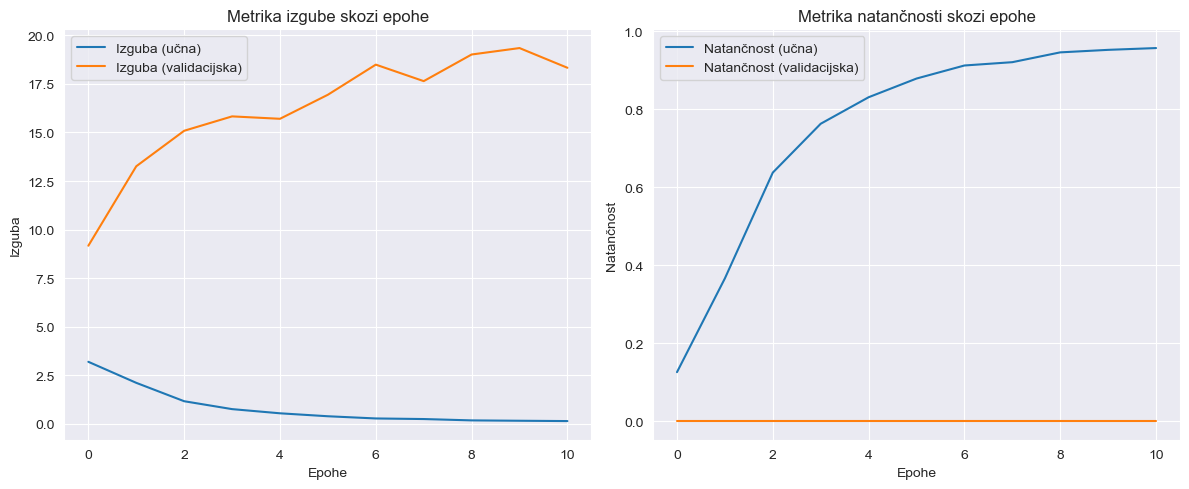

In [38]:
history_data = history.history # Ali naloženo iz .pkl datoteke

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_data['loss'], label='Izguba (učna)')
plt.plot(history_data['val_loss'], label='Izguba (validacijska)')
plt.title('Metrika izgube skozi epohe')
plt.xlabel('Epohe')
plt.ylabel('Izguba')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_data['accuracy'], label='Natančnost (učna)')
plt.plot(history_data['val_accuracy'], label='Natančnost (validacijska)')
plt.title('Metrika natančnosti skozi epohe')
plt.xlabel('Epohe')
plt.ylabel('Natančnost')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()